In [ ]:
pip install datasets torch
pip install accelerate -U
pip install transformers -U




[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [1]:
'''
Examples of tokenization

Sometimes they do unsual things:

Ġ is a special character called the "zero-width non-joiner" represented as U+2581.
It is used in the tokenization process of GPT-2,
which utilize the byte pair encoding (BPE) method.

'''

from transformers import GPT2Tokenizer

tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
text1 = "intensification"
tokens = tokenizer.tokenize(text1)

# return_tensors="pt": the tokenizer will output the sequence of tokens as a PyTorch tensor
input_ids = tokenizer.encode(text1, return_tensors="pt")

print("Text:", text1)
print("Tokens:", tokens)
print("Input IDs:", input_ids)

text2 = "how are you?"
tokens = tokenizer.tokenize(text2)
input_ids = tokenizer.encode(text2, return_tensors="pt")

print("Text:", text2)
print("Tokens:", tokens)
print("Input IDs:", input_ids)


# Note in the tokenization, there is no Ġ in front of "lock", because it is
# not a new word following the previous word.
text3 = "unlock the door"
tokens = tokenizer.tokenize(text3)
input_ids = tokenizer.encode(text3, return_tensors="pt")

print("Text:", text3)
print("Tokens:", tokens)
print("Input IDs:", input_ids)


Text: intensification
Tokens: ['int', 'ens', 'ification']
Input IDs: tensor([[ 600,  641, 2649]])
Text: how are you?
Tokens: ['how', 'Ġare', 'Ġyou', '?']
Input IDs: tensor([[4919,  389,  345,   30]])
Text: unlock the door
Tokens: ['un', 'lock', 'Ġthe', 'Ġdoor']
Input IDs: tensor([[ 403, 5354,  262, 3420]])


In [3]:
input_ids.shape

torch.Size([1, 4])

In [4]:
import torch


# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [5]:
# Decode text output

new_text = 'to be or not to be'

# 1. this is the same as tokenizer.tokenize(text2)
# 2. the to(device) at the end is very important -- otherwise this quantity exists on cpu
input_ids = tokenizer.encode(new_text, return_tensors="pt").to(device)


In [6]:
# define model

from transformers import GPT2LMHeadModel

model = GPT2LMHeadModel.from_pretrained("gpt2").to(device)

# Generate output
output = model.generate(input_ids, max_length=50)

print(output[0])

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


tensor([1462,  307,  393,  407,  284,  307,   13,  198,  198,  464,  717, 1517,
         284,  466,  318,  284,  787, 1654,  326,  345,  389,  407, 1262,  262,
        2642, 3788,   13,  198,  198, 1532,  345,  389, 1262,  257, 1180, 3788,
          11,  345,  815,  307, 1498,  284,  779,  340, 1231,  597, 2761,   13,
         198,  198])


In [7]:
generated_text = tokenizer.decode(output[0], skip_special_tokens=True)
print(generated_text)

to be or not to be.

The first thing to do is to make sure that you are not using the wrong software.

If you are using a different software, you should be able to use it without any problems.




In [8]:
model.save_pretrained('./my_finetuned_gpt2')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [9]:
# You can also save it to google drive -- see notebooks from before

## Pandas


In [10]:
import pandas as pd

# Creating a DataFrame
data = {
    'Name': ['Alice', 'Sanjay', 'Charlie', 'David', 'Maya'],
    'Age': [25, 30, 35, 40, 45],
    'City': ['New York', 'Seattle', 'Chicago', 'San Francisco', 'Phoenix']
}



df = pd.DataFrame(data)

# Extending with more entries
additional_data = {
    'Name': ['Ada', 'Grace', 'Helen', 'Ian', 'Julia', 'Ming', 'Linda', 'Mike', 'Nora', 'Oliver'],
    'Age': [50, 55, 60, 65, 70, 75, 80, 85, 90, 95],
    'City': ['San Francisco', 'Chicago', 'Seattle', 'Denver', 'Atlanta', 'Dallaa', 'Seattle', 'San Francisco', 'Dallas', 'Phoenix']
}

# Creating an extended DataFrame
extended_data = pd.DataFrame(additional_data)
long_df = pd.concat([df, extended_data], ignore_index=True)


long_df


,Name,Age,City
0,Alice,25,New York
1,Sanjay,30,Seattle
2,Charlie,35,Chicago
3,David,40,San Francisco
4,Maya,45,Phoenix
5,Ada,50,San Francisco
6,Grace,55,Chicago
7,Helen,60,Seattle
8,Ian,65,Denver
9,Julia,70,Atlanta


In [11]:
# Saving the DataFrame to a CSV file
csv_path = 'friends.csv'
long_df.to_csv(csv_path, index=False)

csv_path

'friends.csv'

In [12]:
long_df

,Name,Age,City
0,Alice,25,New York
1,Sanjay,30,Seattle
2,Charlie,35,Chicago
3,David,40,San Francisco
4,Maya,45,Phoenix
5,Ada,50,San Francisco
6,Grace,55,Chicago
7,Helen,60,Seattle
8,Ian,65,Denver
9,Julia,70,Atlanta


In [13]:
print(long_df)

       Name  Age           City
0     Alice   25       New York
1    Sanjay   30        Seattle
2   Charlie   35        Chicago
3     David   40  San Francisco
4      Maya   45        Phoenix
5       Ada   50  San Francisco
6     Grace   55        Chicago
7     Helen   60        Seattle
8       Ian   65         Denver
9     Julia   70        Atlanta
10     Ming   75         Dallaa
11    Linda   80        Seattle
12     Mike   85  San Francisco
13     Nora   90         Dallas
14   Oliver   95        Phoenix


In [14]:
import pandas as pd

# Load data from a CSV file
df = pd.read_csv('friends.csv')

# Display the first few rows of the dataframe
print(df.head())


      Name  Age           City
0    Alice   25       New York
1   Sanjay   30        Seattle
2  Charlie   35        Chicago
3    David   40  San Francisco
4     Maya   45        Phoenix


In [15]:
df.tail()

,Name,Age,City
10,Ming,75,Dallaa
11,Linda,80,Seattle
12,Mike,85,San Francisco
13,Nora,90,Dallas
14,Oliver,95,Phoenix


In [16]:
df

,Name,Age,City
0,Alice,25,New York
1,Sanjay,30,Seattle
2,Charlie,35,Chicago
3,David,40,San Francisco
4,Maya,45,Phoenix
5,Ada,50,San Francisco
6,Grace,55,Chicago
7,Helen,60,Seattle
8,Ian,65,Denver
9,Julia,70,Atlanta


In [17]:
df['Age'] >= 65

0     False
1     False
2     False
3     False
4     False
5     False
6     False
7     False
8      True
9      True
10     True
11     True
12     True
13     True
14     True
Name: Age, dtype: bool

In [18]:
# Assume 'df' is a DataFrame containing employee data
older_friends = df[df['Age'] >= 65]

# Display the result
print(older_friends)

      Name  Age           City
8      Ian   65         Denver
9    Julia   70        Atlanta
10    Ming   75         Dallaa
11   Linda   80        Seattle
12    Mike   85  San Francisco
13    Nora   90         Dallas
14  Oliver   95        Phoenix


In [19]:
sf_age = df[df['City'] == 'San Francisco']['Age'].mean()

# Display the result
print(sf_age)

58.333333333333336


In [20]:
# Adding a new column
df['Age_in_2020'] = df['Age'] - 4

# Removing a column
df.drop('Age', axis=1, inplace=True)

In [21]:
df

,Name,City,Age_in_2020
0,Alice,New York,21
1,Sanjay,Seattle,26
2,Charlie,Chicago,31
3,David,San Francisco,36
4,Maya,Phoenix,41
5,Ada,San Francisco,46
6,Grace,Chicago,51
7,Helen,Seattle,56
8,Ian,Denver,61
9,Julia,Atlanta,66


## Breakout Exercise 1: Load and Inspect Data
Load the Iris dataset from a provided CSV file and display the first and last 5 rows of the dataset. Additionally, print the summary statistics of the dataset.


In [7]:
import pandas as pd

# Load dataset
iris_path = '/Users/jjburrell/Downloads/iris.csv'
iris_df = pd.read_csv(iris_path)

# Display first 5 rows
print("First 5 rows:")
print(iris_df.head())

# Display last 5 rows
print("\nLast 5 rows:")
print(iris_df.tail())

# Summary statistics
print("\nSummary statistics:")
print(iris_df.describe())

First 5 rows:
   sepal.length  sepal.width  petal.length  petal.width variety
0           5.1          3.5           1.4          0.2  Setosa
1           4.9          3.0           1.4          0.2  Setosa
2           4.7          3.2           1.3          0.2  Setosa
3           4.6          3.1           1.5          0.2  Setosa
4           5.0          3.6           1.4          0.2  Setosa

Last 5 rows:
     sepal.length  sepal.width  petal.length  petal.width    variety
145           6.7          3.0           5.2          2.3  Virginica
146           6.3          2.5           5.0          1.9  Virginica
147           6.5          3.0           5.2          2.0  Virginica
148           6.2          3.4           5.4          2.3  Virginica
149           5.9          3.0           5.1          1.8  Virginica

Summary statistics:
       sepal.length  sepal.width  petal.length  petal.width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.057333 

## Breakout Exercise 2: Data Filtering

From the loaded Iris dataset, extract rows where the petal length is greater than 1.5 and petal width is less than 0.5.

In [11]:
# Filter rows: petal length > 1.5 and petal width < 0.5
filtered_df = iris_df[
    (iris_df['petal.length'] > 1.5) & 
    (iris_df['petal.width'] < 0.5)
]

print("\nFiltered rows (petal_length > 1.5 and petal_width < 0.5):")
print(filtered_df)


Filtered rows (petal_length > 1.5 and petal_width < 0.5):
    sepal.length  sepal.width  petal.length  petal.width variety
5            5.4          3.9           1.7          0.4  Setosa
11           4.8          3.4           1.6          0.2  Setosa
18           5.7          3.8           1.7          0.3  Setosa
20           5.4          3.4           1.7          0.2  Setosa
24           4.8          3.4           1.9          0.2  Setosa
25           5.0          3.0           1.6          0.2  Setosa
26           5.0          3.4           1.6          0.4  Setosa
29           4.7          3.2           1.6          0.2  Setosa
30           4.8          3.1           1.6          0.2  Setosa
44           5.1          3.8           1.9          0.4  Setosa
46           5.1          3.8           1.6          0.2  Setosa


## Break Exercise 3: Column Operations

Add a new column to the Iris dataset called 'sepal_area' calculated as the product of sepal length and sepal width.

In [13]:
iris_df['sepal.area'] = iris_df['sepal.length'] * iris_df['sepal.width']

print("\nDataset with new 'sepal_area' column:")
print(iris_df.head())


Dataset with new 'sepal_area' column:
   sepal.length  sepal.width  petal.length  petal.width variety  sepal.area
0           5.1          3.5           1.4          0.2  Setosa       17.85
1           4.9          3.0           1.4          0.2  Setosa       14.70
2           4.7          3.2           1.3          0.2  Setosa       15.04
3           4.6          3.1           1.5          0.2  Setosa       14.26
4           5.0          3.6           1.4          0.2  Setosa       18.00


## Breakout Exercise 4: Data Grouping and Visualization

Group the Iris dataset by species, compute the average of all numeric columns for each species, and create a bar chart visualizing

- the average sepal length and petal length for each species.
- the average sepal width and petal width for each species.
- the average sepal length and sepal width for each species.
- the average petal length and petal width for each species.

Grouped means:
            sepal.length  sepal.width  petal.length  petal.width
variety                                                         
Setosa             5.006        3.428         1.462        0.246
Versicolor         5.936        2.770         4.260        1.326
Virginica          6.588        2.974         5.552        2.026


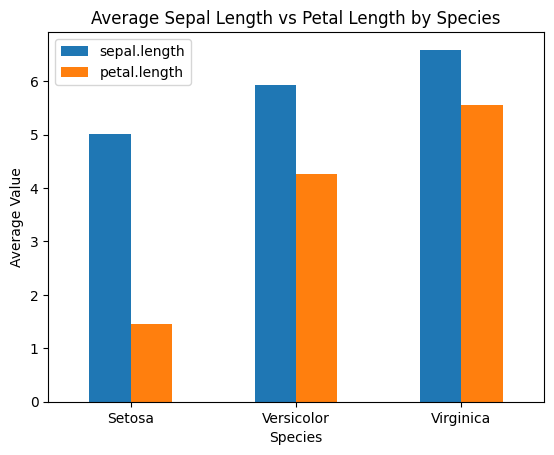

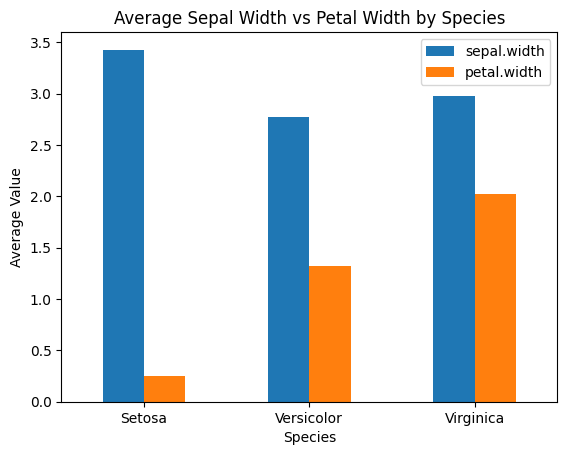

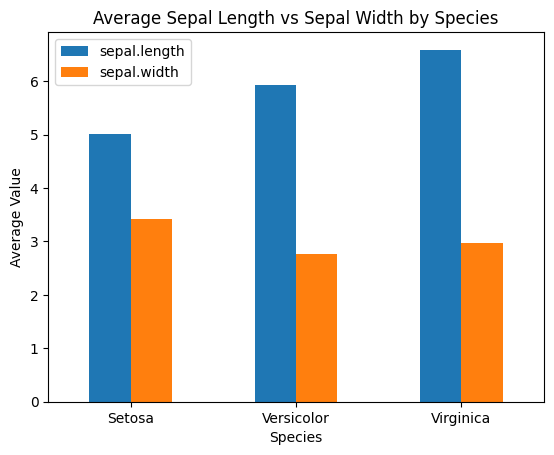

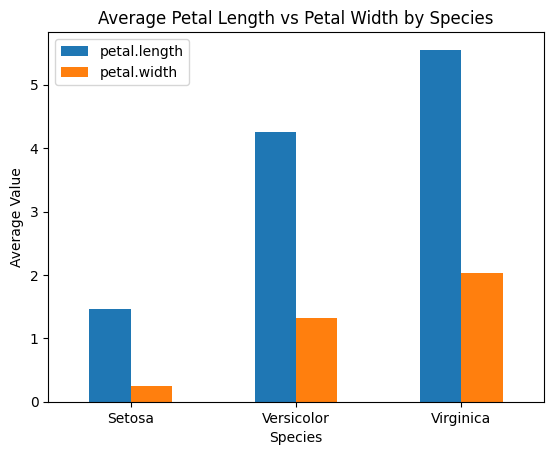

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

iris_df.columns = iris_df.columns.str.strip().str.lower().str.replace(" ", "_")

grouped = iris_df.groupby('variety').mean(numeric_only=True)

print("Grouped means:")
print(grouped)

grouped[['sepal.length', 'petal.length']].plot(kind='bar')
plt.title("Average Sepal Length vs Petal Length by Species")
plt.xlabel("Species")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.show()

grouped[['sepal.width', 'petal.width']].plot(kind='bar')
plt.title("Average Sepal Width vs Petal Width by Species")
plt.xlabel("Species")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.show()

grouped[['sepal.length', 'sepal.width']].plot(kind='bar')
plt.title("Average Sepal Length vs Sepal Width by Species")
plt.xlabel("Species")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.show()

grouped[['petal.length', 'petal.width']].plot(kind='bar')
plt.title("Average Petal Length vs Petal Width by Species")
plt.xlabel("Species")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.show()

## Breakout Exercise 5:

- Use two of the four measurements (petal length and width, septal length and width) to building a MLP classifier for the iris varieities

        (Later, you can also consider to show the boundaries on this 2D space)
        
- Use all four features to classify


In [19]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

iris_df.columns = iris_df.columns.str.strip().str.lower().str.replace(" ", "_")

iris_df = iris_df.rename(columns={'variety': 'species'})

X = iris_df[['sepal.length', 'sepal.width', 'petal.length', 'petal.width']]
y = iris_df['species']

In [20]:
def train_mlp(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    model = MLPClassifier(hidden_layer_sizes=(10, 10), max_iter=1000, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    return model, scaler, acc

In [21]:
X_petal = iris_df[['petal.length', 'petal.width']]
model_petal, scaler_petal, acc_petal = train_mlp(X_petal, y)

print("Accuracy (petal features):", acc_petal)

Accuracy (petal features): 1.0


In [22]:
X_sepal = iris_df[['sepal.length', 'sepal.width']]
model_sepal, scaler_sepal, acc_sepal = train_mlp(X_sepal, y)

print("Accuracy (sepal features):", acc_sepal)

Accuracy (sepal features): 0.9


In [23]:
model_all, scaler_all, acc_all = train_mlp(X, y)

print("Accuracy (all features):", acc_all)

Accuracy (all features): 0.9666666666666667


In [24]:
def plot_decision_boundary(X, y, model, scaler, title):
    X_scaled = scaler.transform(X)

    x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
    y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1

    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                         np.linspace(y_min, y_max, 200))

    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    plt.contourf(xx, yy, Z, alpha=0.3)

    plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=pd.factorize(y)[0])
    plt.title(title)
    plt.xlabel(X.columns[0])
    plt.ylabel(X.columns[1])
    plt.show()

TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

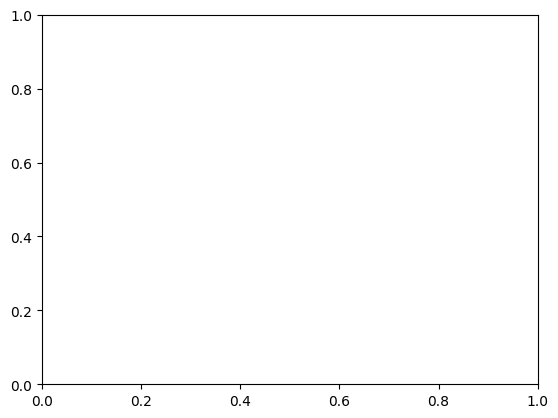

In [28]:
plot_decision_boundary(X_petal, y, model_petal, scaler_petal, "test")

TypeError: ufunc 'isfinite' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

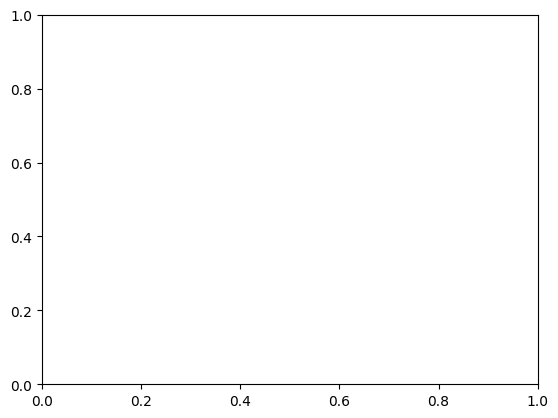

In [29]:
plot_decision_boundary(X_sepal, y, model_sepal, scaler_sepal,
                       "Decision Boundary (Sepal Features)")